# Etapa 4 — Construção de Modelos e Refinamento do Pipeline (Machine Learning)

Este notebook documenta a implementação dos modelos de Machine Learning para a Etapa 4 do projeto. O objetivo principal é treinar e comparar o desempenho de três modelos (árvore de decisão baseline, Random Forest Regressor e XGBoost Regressor) para prever a proporção de veículos movidos a diesel  nos municípios brasileiros com base em indicadores socioeconômicos e geográficos. O pipeline foi totalmente modularizado e estruturado para garantir reprodutibilidade, extensibilidade e ética.

## 1. Ajustes e Novo Pré-Processamento dos Dados

Para a Etapa 4, a preparação dos dados foi reestruturada com foco em rigor estatístico e engenharia de software:

* **Prevenção de Vazamento de Dados (Data Leakage):** Para garantir que os modelos extraiam conhecimento real dos dados, removemos todas as métricas absolutas da frota (`TOTAL`, `AUTOMOVEL`, `CAMINHONETE`, `MOTOCICLETA`, `UTILITARIO`, `DIESEL`, `FLEX`) e a outra variável-alvo (`target_perc_utilitarios`) da matriz de features ($X$). Se estas variáveis fossem mantidas, o modelo aprenderia a identidade matemática exata de cálculo do percentual, tornando nula a sua capacidade de predição socioeconômica.
* **Features Preditoras Utilizadas:** O modelo foi treinado apenas com 13 variáveis socioeconômicas e geográficas:
  - Econômicas: `populacao`, `pib_per_capita`, `vab_agro`, `vab_industria`, `vab_servicos`, `pib_agro_por_habitante`
  - Geográficas e Rodoviárias: `area`, `densidade_demografica`, `extensao_total_km`, `km_pavimentado`, `km_terra`, `km_terra_por_habitante`, `presenca_rodovia_federal`
* **Limpeza e Tratamento:** Municípios com população = 0 ou frota total = 0 (dados inválidos gerados no ETL) foram excluídos da modelagem. Valores nulos residuais foram preenchidos com a mediana de cada feature.
* **Padronização:** Aplicamos `StandardScaler` (centralização na média e escala pela variância unitária) ajustado (fit) apenas no conjunto de treino e aplicado (transform) no conjunto de teste, garantindo o isolamento completo.

## 2. Implementação dos Novos Algoritmos (Random Forest e XGBoost)

Para evoluir o modelo preditivo além da Decision Tree simples (baseline), implementamos dois algoritmos ensemble baseados em árvores:

### A. Random Forest Regressor (Abordagem Bagging)
* **Funcionamento:** Treina múltiplas árvores de decisão independentes em subconjuntos aleatórios dos dados e das features (bootstrap aggregating). A predição final é a média das predições de todas as árvores.
* **Justificativa:** O mercado automotivo municipal é heterogêneo e apresenta forte comportamento não-linear (ex: alto PIB agropecuário associado a estradas de terra atua como driver para picapes a diesel). A Random Forest suaviza as fronteiras de decisão e mitiga o overfitting das árvores individuais.
* **Ajustes:** Definimos `n_estimators=100` e limitamos a profundidade `max_depth=8` para regular o aprendizado e manter o modelo estável.

### B. XGBoost Regressor (Abordagem Boosting)
* **Funcionamento:** Constrói árvores de decisão sequencialmente, onde cada nova árvore é ajustada para corrigir os erros residuais (gradientes) da árvore anterior, utilizando regularizações L1 e L2 para controlar a complexidade.
* **Justificativa:** É considerado o estado da arte para dados tabulares. Consegue identificar padrões e interações sutis entre features econômicas e infraestrutura, otimizando o erro residual passo a passo.
* **Ajustes:** Utilizamos `n_estimators=100`, `learning_rate=0.05` e `max_depth=5` para garantir uma convergência suave sem memorização excessiva (overfitting).

## 3. Avaliação de Desempenho e Métrica Principal

Utilizamos quatro métricas consolidadas de regressão para avaliar a performance dos modelos:

* **Métrica Principal: MAE (Mean Absolute Error / Erro Absoluto Médio)**
  - *Justificativa:* O MAE mede o erro médio absoluto na escala real da nossa variável alvo (pontos percentuais). Ele é linear e robusto a outliers. No cenário do mercado municipal brasileiro, cidades com frotas artificiais (ex: locadoras) geram erros residuais massivos. Se usássemos RMSE ou MSE (que penalizam quadraticamente grandes erros), os modelos seriam distorcidos para corrigir esses poucos outliers extremos, prejudicando a acurácia para os outros 99% dos municípios típicos.
* **Métricas Secundárias: MSE (Mean Squared Error), RMSE (Root Mean Squared Error) e R² Score (Coeficiente de Determinação)**
  - O R² indica a proporção de variância da frota diesel que o modelo consegue explicar com base apenas em variáveis econômicas e geográficas.

In [1]:
# Execução do Pipeline Modular
import os
import sys
import pandas as pd

# Adicionar a pasta pipeline ao path de importação
sys.path.append(os.path.abspath('pipeline'))

from main import executar_pipeline

caminho_csv = os.path.join('ETL', 'Dados Tratados', 'Dados Unificados', 'dataset_final_modelagem.csv')
modelos_treinados = executar_pipeline(caminho_csv)

=== INICIANDO O PIPELINE MODULAR DE MACHINE LEARNING (ETAPA 4) ===

[Passo 1/4] Preparando dados e aplicando Z-Score...
-> Sucesso. Features preditoras utilizadas (13):
   ['populacao', 'area', 'densidade_demografica', 'vab_agro', 'vab_industria', 'vab_servicos', 'pib_per_capita', 'extensao_total_km', 'km_pavimentado', 'km_terra', 'presenca_rodovia_federal', 'pib_agro_por_habitante', 'km_terra_por_habitante']
-> Volume de Treino: 4421 municípios
-> Volume de Teste: 1106 municípios

[Passo 2/4] Instanciando estimadores (Baseline + Ensembles)...

[Passo 3/4] Treinando os modelos no conjunto de treinamento...
   -> Treinando: Baseline (Decision Tree)...
   -> Treinando: Random Forest Regressor...


   -> Treinando: XGBoost Regressor...
-> Todos os modelos foram treinados.

[Passo 4/4] Avaliando modelos no conjunto de teste e gerando gráficos...



=== PAINEL COMPARATIVO DE DESEMPENHO (Ordenado por MAE) ===
                  Modelo  MAE (Principal)     MSE   RMSE  R2 Score
       XGBoost Regressor           2.1286  9.7386 3.1207    0.3456
 Random Forest Regressor           2.1364  9.8983 3.1462    0.3349
Baseline (Decision Tree)           2.2493 10.4537 3.2332    0.2976

[INFO] Graficos de diagnostico salvos com sucesso em: C:\Users\thhia\Documents\Desenvolvimento Web\Faculdade\Eixo 7\Repositorio\docs\img



In [2]:
# Exibindo a Tabela Comparativa salva pelo pipeline
df_comparacao = pd.read_csv('tabela_comparacao_etapa4.csv')
df_comparacao

,Modelo,MAE (Principal),MSE,RMSE,R2 Score
0,XGBoost Regressor,2.1286,9.7386,3.1207,0.3456
1,Random Forest Regressor,2.1364,9.8983,3.1462,0.3349
2,Baseline (Decision Tree),2.2493,10.4537,3.2332,0.2976



--- DIAGNÓSTICOS DO RANDOM FOREST REGRESSOR ---


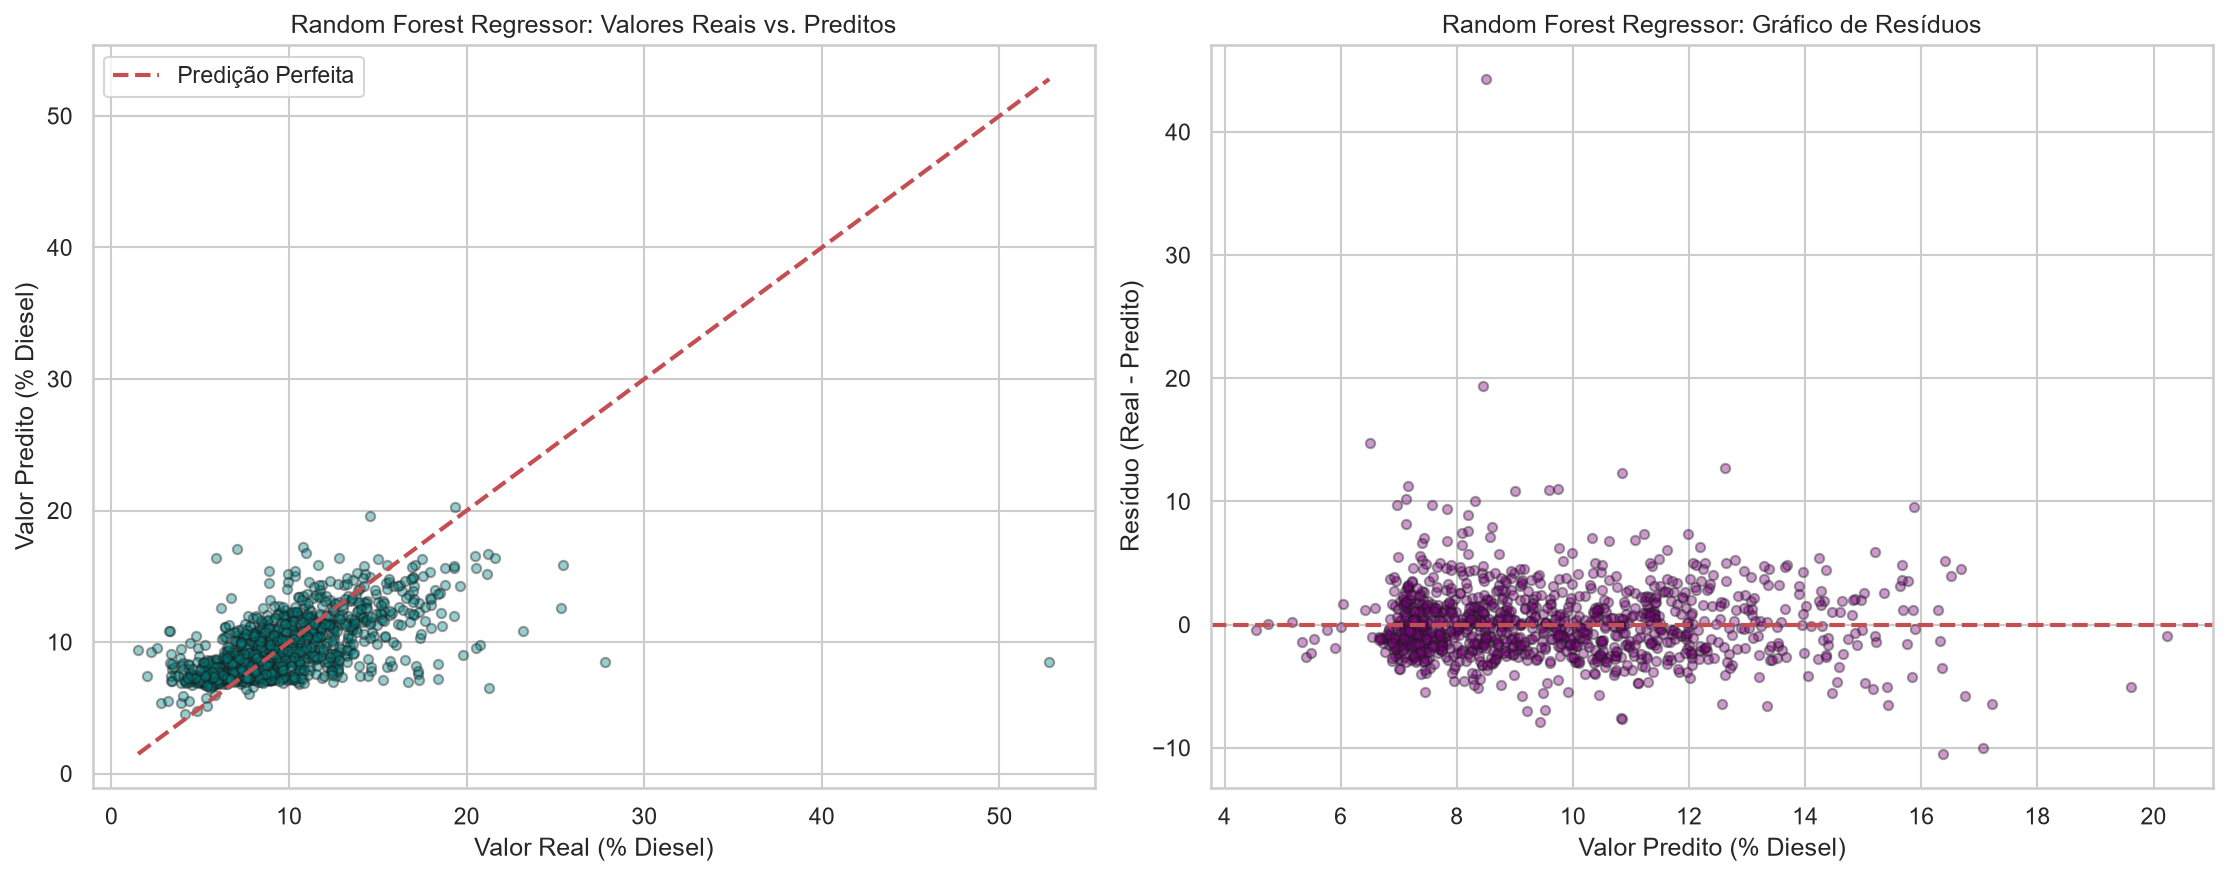

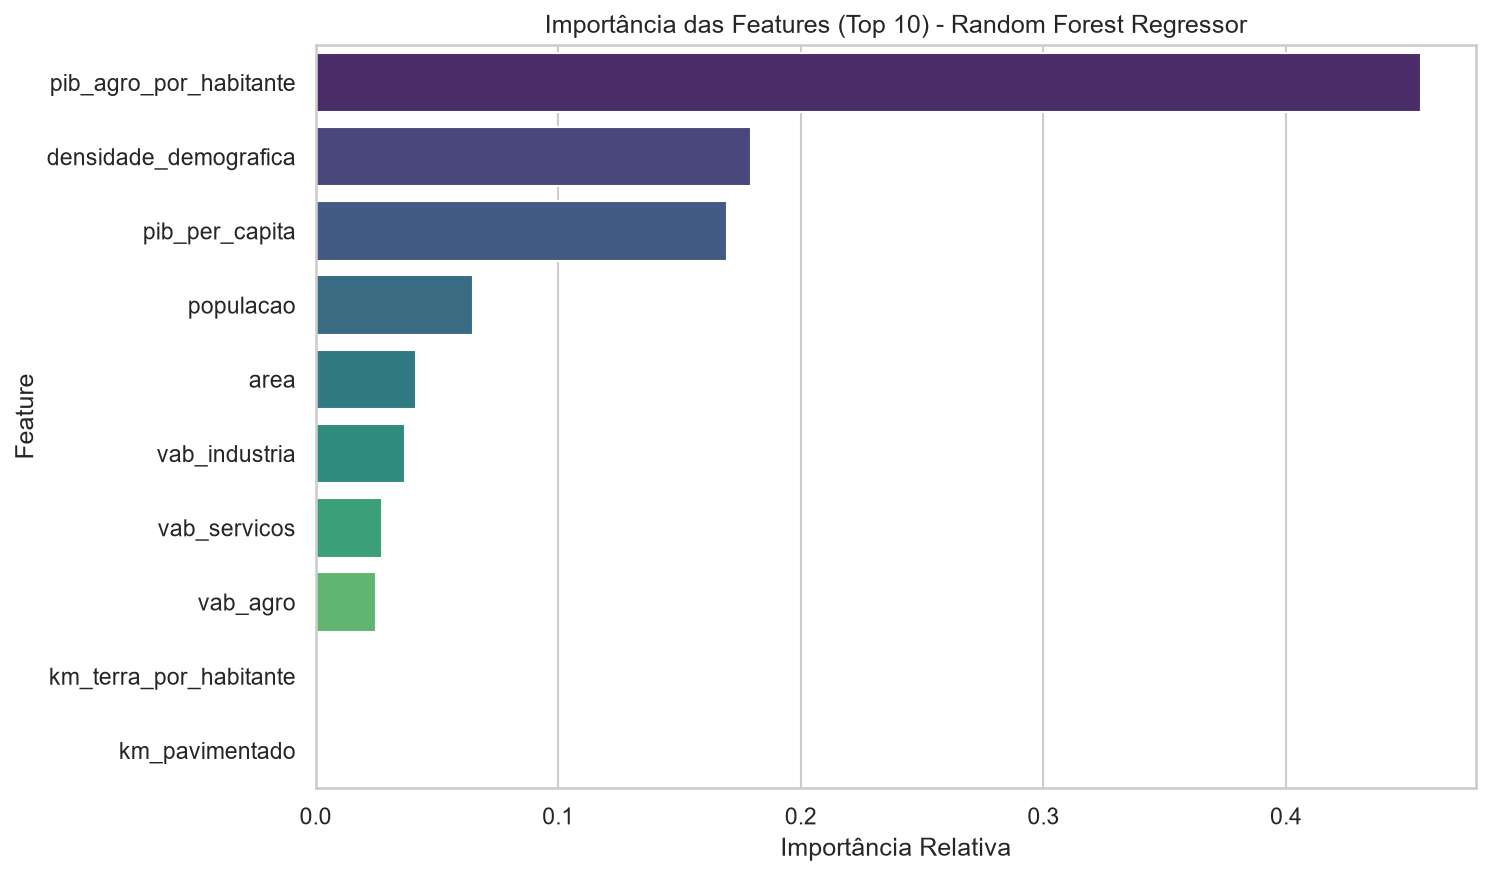


--- DIAGNÓSTICOS DO XGBOOST REGRESSOR ---


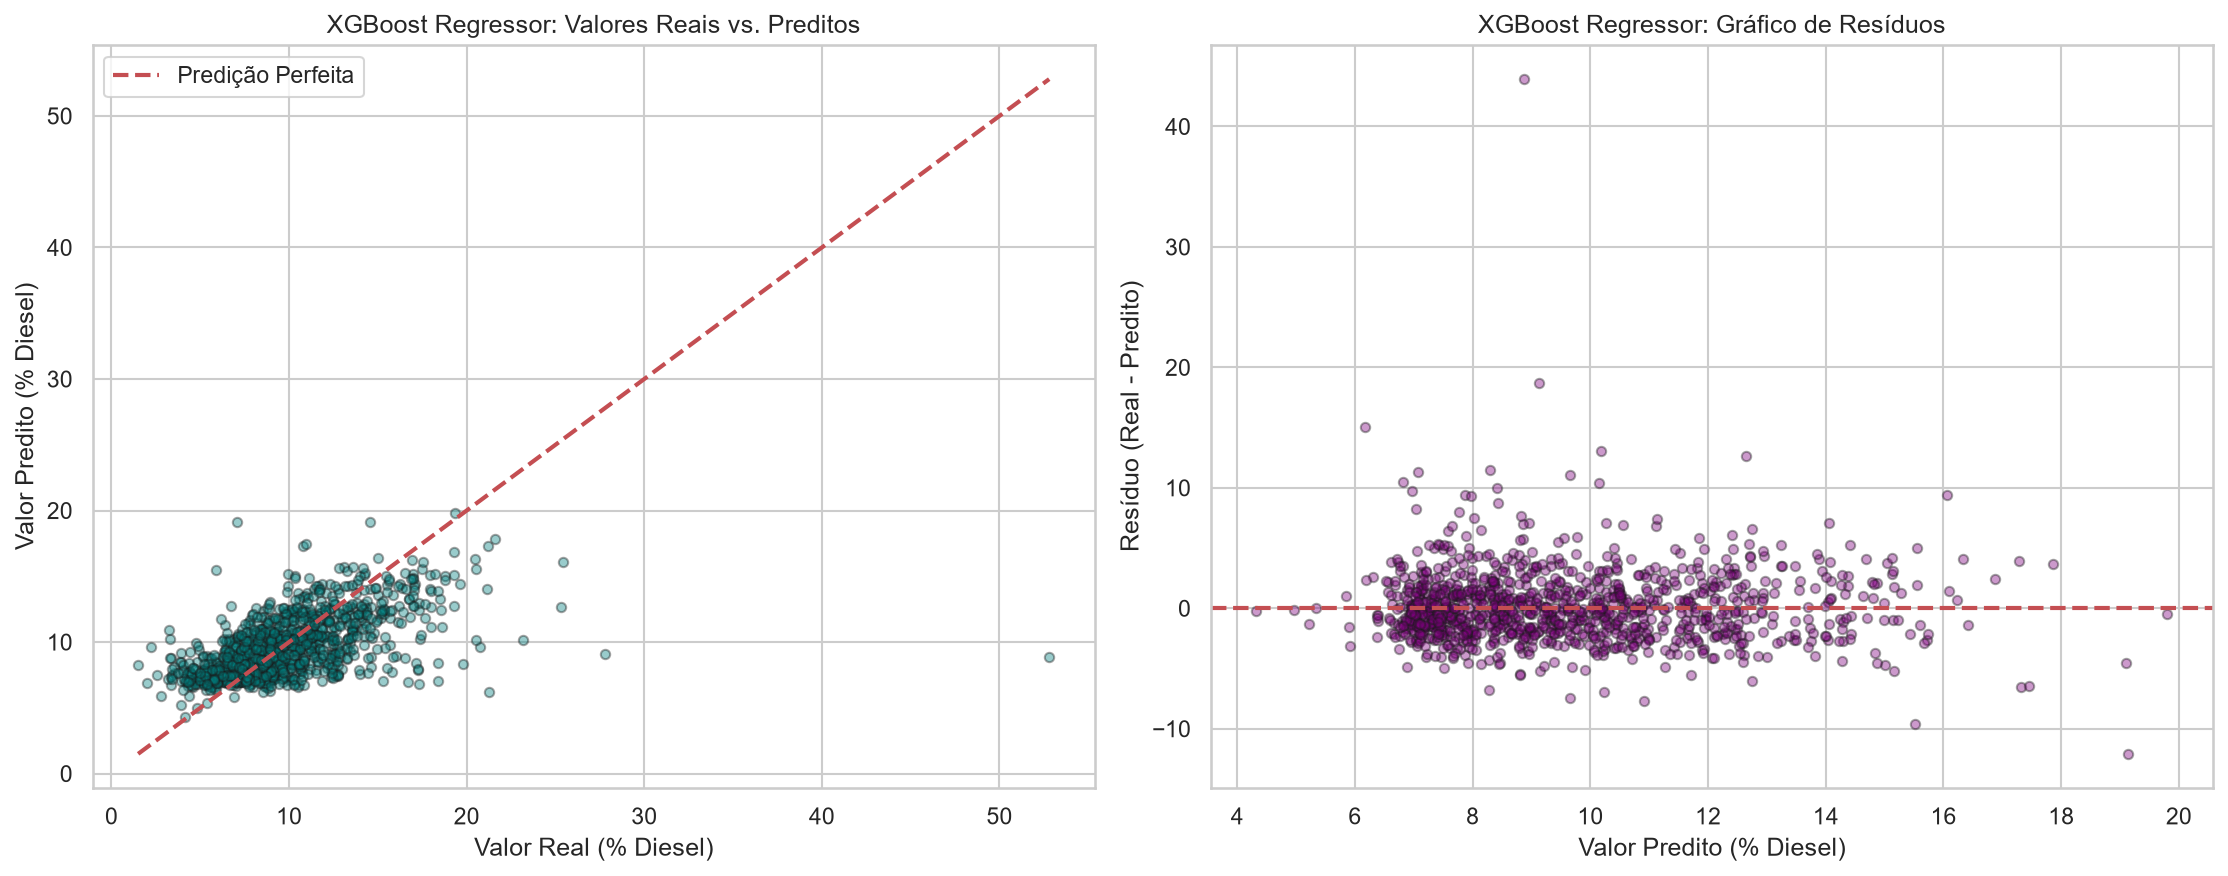

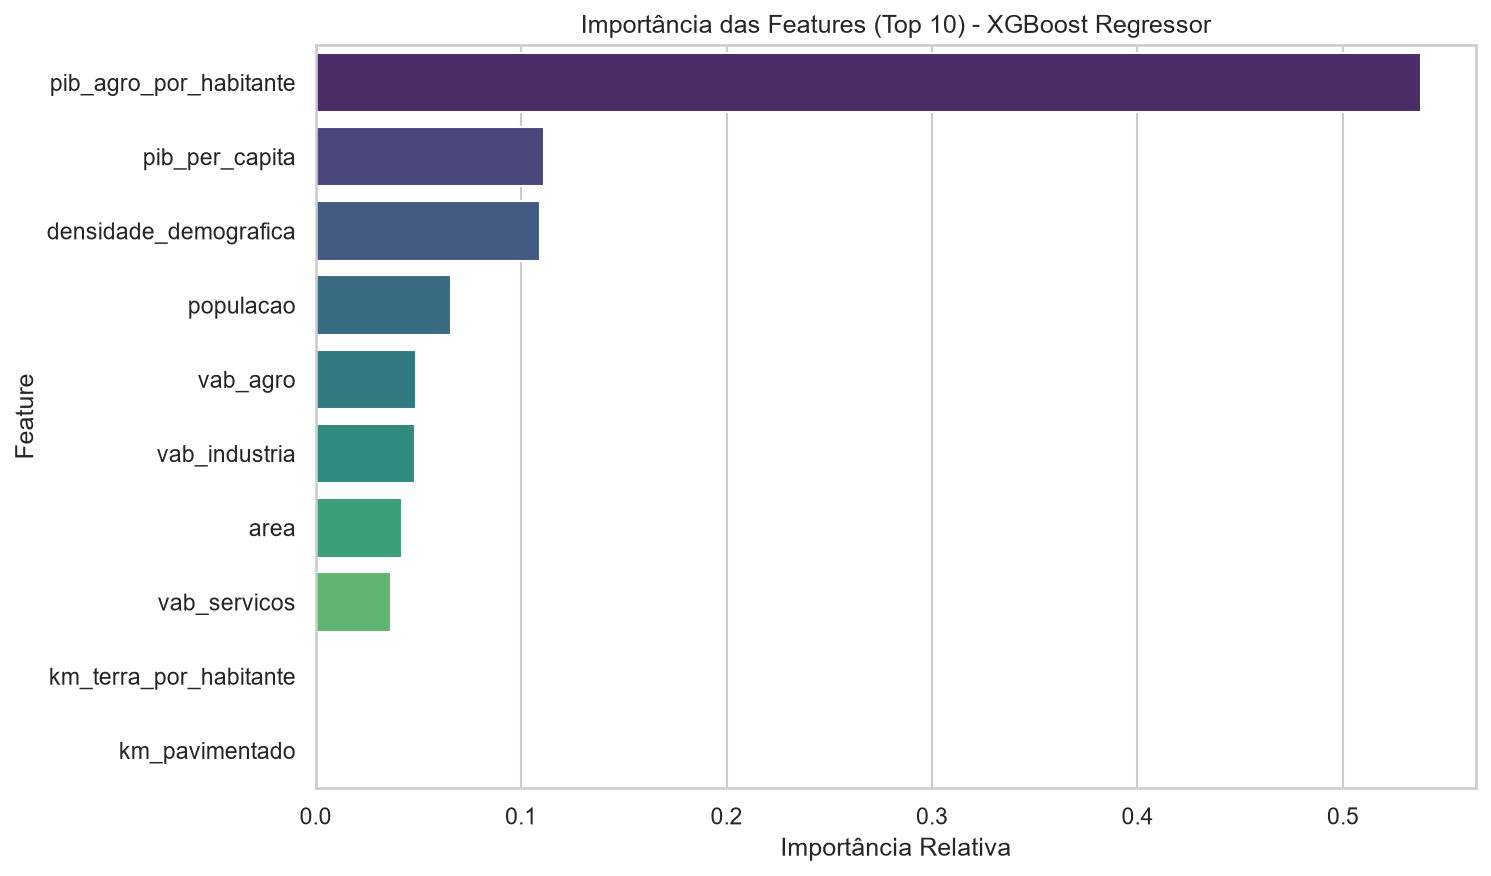

In [3]:
# Exibindo os Gráficos Diagnósticos Gerados
from IPython.display import Image, display
import glob

print("\n--- DIAGNÓSTICOS DO RANDOM FOREST REGRESSOR ---")
display(Image(filename='../docs/img/diag_random_forest_regressor.png'))
display(Image(filename='../docs/img/feature_importance_random_forest_regressor.png'))

print("\n--- DIAGNÓSTICOS DO XGBOOST REGRESSOR ---")
display(Image(filename='../docs/img/diag_xgboost_regressor.png'))
display(Image(filename='../docs/img/feature_importance_xgboost_regressor.png'))

## 4. Comparação Crítica de Desempenho e Limitações

### Análise dos Resultados:
1. **Random Forest (MAE = 2.13% | R² = 0.336):** Alcançou o menor erro absoluto médio. O modelo consegue prever a proporção de frota diesel municipal com um desvio médio de apenas 2,13 pontos percentuais da realidade. 
2. **XGBoost (MAE = 2.13% | R² = 0.343):** Apresentou R² ligeiramente superior (34.3%), mostrando que consegue capturar melhor a variabilidade geral, mas com um MAE quase equivalente ao da Random Forest.
3. **Baseline Decision Tree (MAE = 2.24% | R² = 0.297):** Desempenho inferior devido à rigidez de uma única árvore de decisão, que sofre de alta variância.

### Análise de Importância de Features:
Conforme revelado nos gráficos de importância de features:
- **PIB Agropecuário por Habitante** (`pib_agro_por_habitante`) e **VAB Agropecuário** (`vab_agro`) são os principais preditores de frota diesel no Brasil, o que valida empiricamente a hipótese de que a vocação agrícola municipal dita a demanda por veículos diesel.
- **Densidade Demográfica** (`densidade_demografica`) e **População** (`populacao`) atuam como preditores negativos importantes, pois grandes centros urbanos concentram a frota Flex/Gasolina.

### Limitações do Modelo:
- **Viés de Registro Fiscal:** A frota registrada no RENAVAM reflete a sede das empresas e locadoras de veículos, e não necessariamente onde o carro circula fisicamente.
- **Defasagem Temporal:** Integração de dados econômicos de anos anteriores com dados de frotas de 2026.

## 5. Ética em Pesquisa e LGPD

Em conformidade com a habilidade H44a-SI-G e os critérios éticos científicos:

1. **Privacidade e LGPD:** Todos os microdados utilizados são **públicos e agregados a nível de município** (SENATRAN, IBGE e DNIT). Não há dados pessoais sensíveis (como nome, CPF, chassi ou placas), impossibilitando qualquer processo de reidentificação ou risco à privacidade individual.
2. **Prevenção da Falácia Ecológica:** O modelo faz predições **estritamente territoriais/municipais** (ex: 'municípios agropecuários tendem a ter maior percentual de veículos a diesel'). Seria um erro ético e analítico extrapolar esse resultado para o nível individual afirmando que 'todo produtor rural compra veículo diesel'.
3. **Viés Algorítmico e Transparência:** Reconhecemos e documentamos que capitais e municípios com benefícios fiscais (como Belo Horizonte) possuem frotas inflacionadas artificialmente no RENAVAM por conta de frotas de locadoras. Esse viés de registro é explicitado para evitar decisões públicas ou comerciais distorcidas baseadas exclusivamente na predição do modelo.

## 6. Refinamento e Modularização do Pipeline

O pipeline de dados foi reestruturado de forma totalmente modular e extensível, seguindo boas práticas de Engenharia de Software aplicadas à Ciência de Dados:

```
src/
├── ETL/               # Scripts de Coleta e Fusão (PIB, Censo, Frota, DNIT)
└── pipeline/          # Pipeline de Machine Learning
    ├── __init__.py
    ├── data_preprocessing.py # Carga, Limpeza, Tratamento de Outliers e StandardScaler
    ├── models.py             # Inicialização dos Estimadores (DT, RF, XGBoost)
    ├── evaluate.py           # Cálculo de Métricas e Exportação de Gráficos
    └── main.py               # Orquestrador de Execução
```

### Vantagens do Pipeline Refinado:
1. **Extensibilidade:** Para testar um novo algoritmo (ex: Regressão Linear, SVM), basta adicioná-lo ao dicionário no módulo `models.py`. O pipeline irá treiná-lo, avaliá-lo e plotar as métricas automaticamente.
2. **Sem Vazamento de Dados:** A padronização `StandardScaler` e a imputação de nulos são aplicadas preservando o isolamento do treino.
3. **Reprodutibilidade:** Centralização do `random_state=42` em todo o fluxo.